In [105]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score



In [106]:
df=pd.read_csv("air_quality.csv")
df.head()

,co,no,no2,o3,so2,pm2_5,pm10,nh3,aqi,timestamp
0,121.65,0.00,0.09,48.27,0.38,13.39,56.86,0.0,3,1775523600
1,122.08,0.00,0.10,49.03,0.39,13.57,58.38,0.0,3,1775527200
2,122.55,0.00,0.10,49.81,0.39,13.70,59.07,0.0,3,1775530800
3,122.64,0.01,0.09,51.10,0.40,13.90,59.45,0.0,3,1775534400
4,123.01,0.02,0.09,54.25,0.44,14.28,59.92,0.0,3,1775538000


In [107]:
df.describe(
)

,co,no,no2,o3,so2,pm2_5,pm10,nh3,aqi,timestamp
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2.106000e+03
mean,90.897365,0.004639,0.080161,58.432365,0.394786,21.750451,82.530223,0.003371,3.097816,1.779412e+09
std,21.144782,0.005478,0.037809,24.061538,0.180740,11.354851,45.417843,0.027401,0.671033,2.262238e+06
min,65.470000,0.000000,0.030000,31.330000,0.120000,6.800000,30.110000,0.000000,2.000000,1.775524e+09
25%,73.022500,0.000000,0.060000,43.105000,0.280000,13.622500,57.255000,0.000000,3.000000,1.777418e+09
50%,82.120000,0.000000,0.070000,48.210000,0.360000,18.905000,75.665000,0.000000,3.000000,1.779485e+09
75%,109.250000,0.010000,0.100000,70.322500,0.450000,28.962500,99.005000,0.000000,4.000000,1.781380e+09
max,144.890000,0.030000,0.360000,149.490000,1.600000,112.910000,647.240000,0.440000,5.000000,1.783274e+09


In [108]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   co         2106 non-null   float64
 1   no         2106 non-null   float64
 2   no2        2106 non-null   float64
 3   o3         2106 non-null   float64
 4   so2        2106 non-null   float64
 5   pm2_5      2106 non-null   float64
 6   pm10       2106 non-null   float64
 7   nh3        2106 non-null   float64
 8   aqi        2106 non-null   int64  
 9   timestamp  2106 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 164.7 KB


In [109]:
df.isnull().sum()

co           0
no           0
no2          0
o3           0
so2          0
pm2_5        0
pm10         0
nh3          0
aqi          0
timestamp    0
dtype: int64

In [110]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2101    False
2102    False
2103    False
2104    False
2105    False
Length: 2106, dtype: bool

In [111]:
df.shape

(2106, 10)

In [112]:
df.columns

Index(['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3', 'aqi',
       'timestamp'],
      dtype='str')

In [113]:
numeric_values=['co','no2', 'o3', 'so2', 'pm2_5', 'pm10', 'aqi']

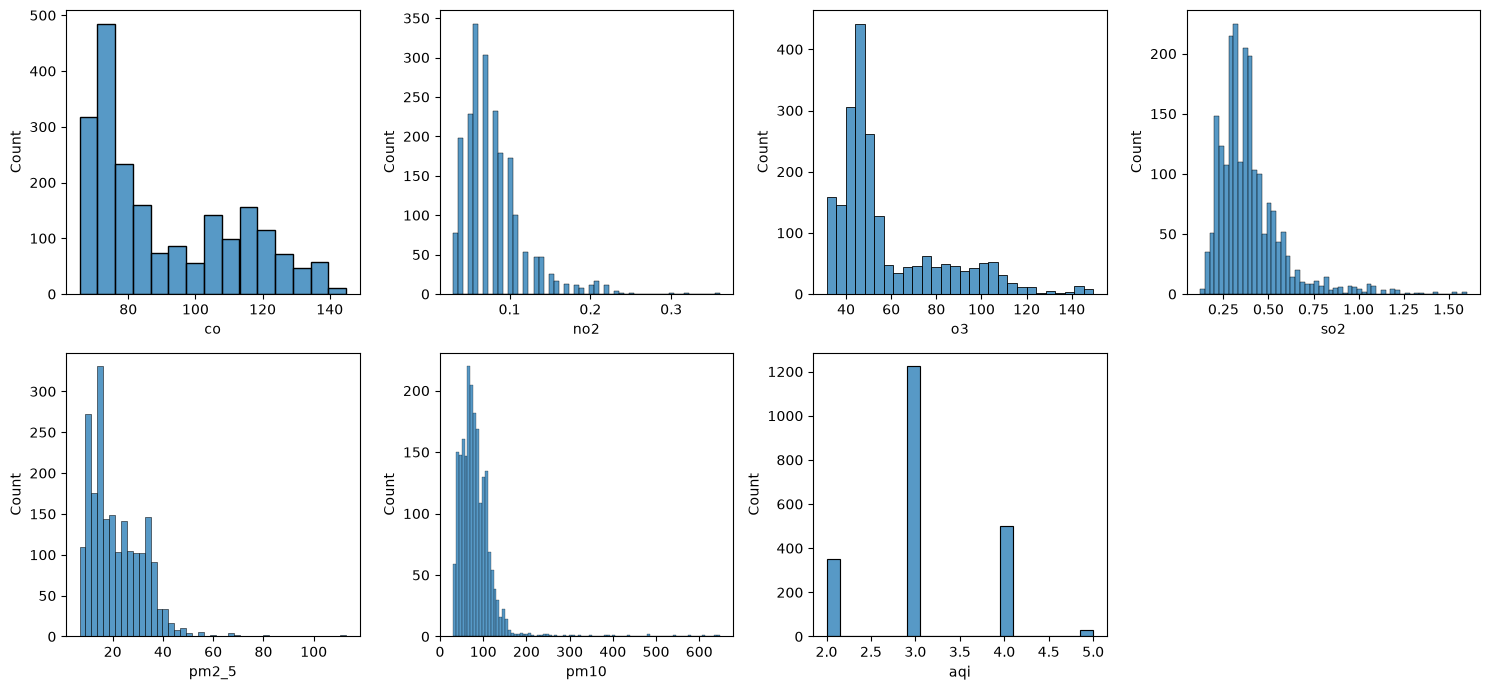

In [114]:
plt.figure(figsize=(15,10))
for i,cols in enumerate(numeric_values):
    plt.subplot(3,4,i+1)
    sns.histplot(df[cols])
plt.tight_layout()
plt.show()

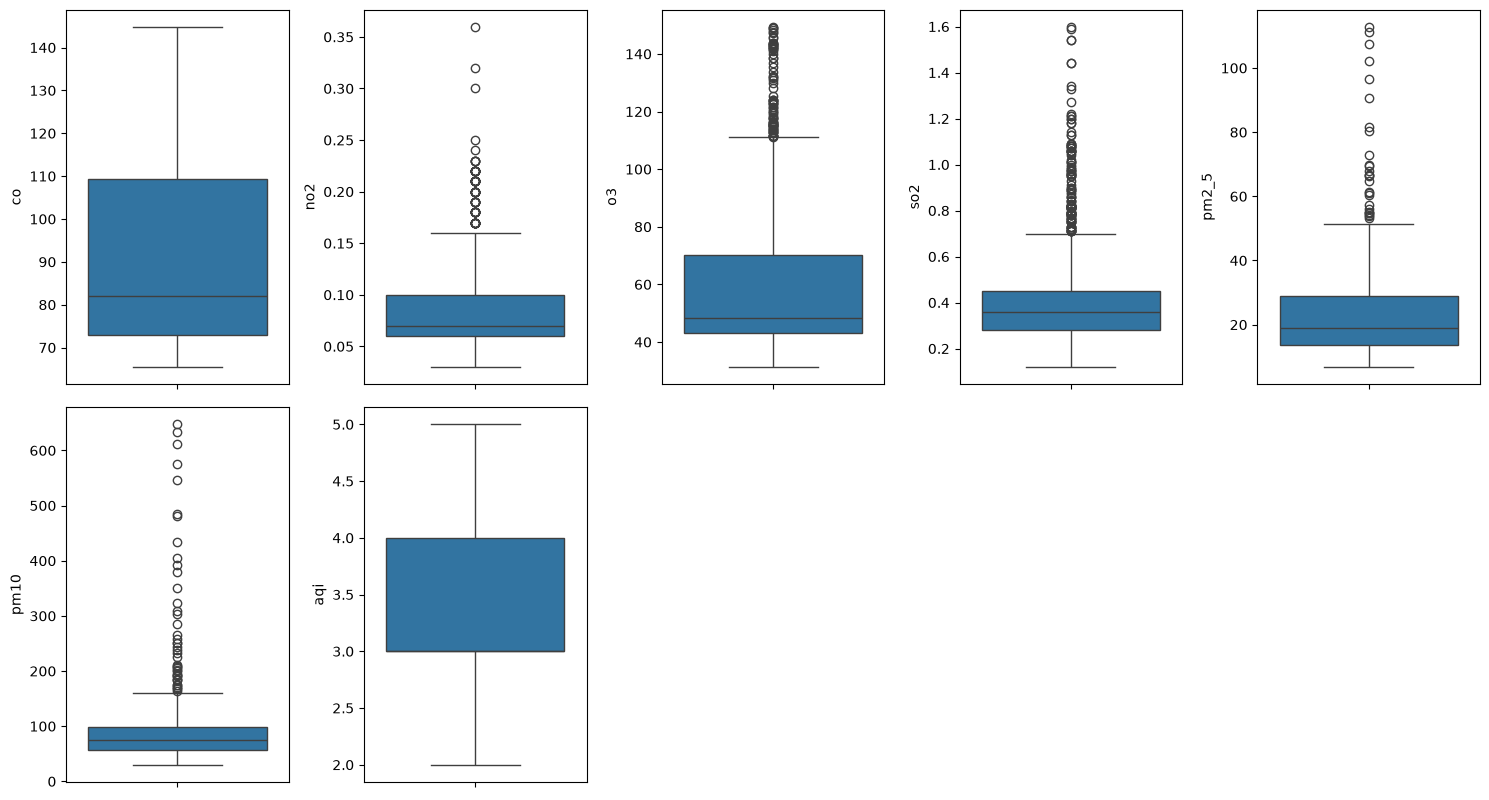

In [115]:
plt.figure(figsize=(15,12))
for i,cols in enumerate(numeric_values):
    plt.subplot(3,5,i+1)
    sns.boxplot(df[cols])
plt.tight_layout()
plt.show()

<Axes: >

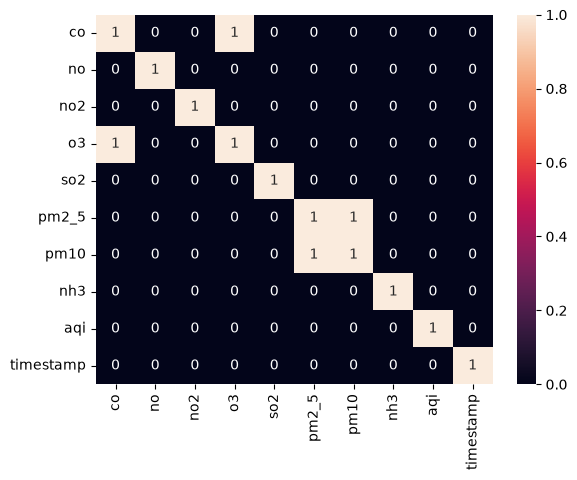

In [116]:
sns.heatmap(df.corr(numeric_only=True)>0.8,annot=True)

In [117]:
df.drop(columns=['co'],inplace=True)

In [118]:
df.columns

Index(['no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3', 'aqi', 'timestamp'], dtype='str')

In [119]:
X=df.drop("aqi",axis=1)
y=df['aqi']

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


In [121]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [122]:
result=[]

In [123]:
models={
    "LogisticRegression":LogisticRegression(),
    "KNN":KNeighborsClassifier(),
    "DecisionTree":DecisionTreeClassifier(),
    "GaussianNB":GaussianNB(),
    "SVM":SVC()
}



In [124]:
df.dtypes

no           float64
no2          float64
o3           float64
so2          float64
pm2_5        float64
pm10         float64
nh3          float64
aqi            int64
timestamp      int64
dtype: object

In [125]:
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    f1=f1_score(y_test,y_pred,average="weighted")
    acc=accuracy_score(y_test,y_pred)
    result.append({
        "model":model,
        "f1_score":f1,
        "accurary":acc
    })
    

In [126]:
result

[{'model': LogisticRegression(),
  'f1_score': 0.9502918885139819,
  'accurary': 0.9502369668246445},
 {'model': KNeighborsClassifier(),
  'f1_score': 0.9264017988072063,
  'accurary': 0.9265402843601895},
 {'model': DecisionTreeClassifier(), 'f1_score': 1.0, 'accurary': 1.0},
 {'model': GaussianNB(),
  'f1_score': 0.7194362383635936,
  'accurary': 0.6445497630331753},
 {'model': SVC(),
  'f1_score': 0.9455791920302759,
  'accurary': 0.9454976303317536}]

In [127]:
result=pd.DataFrame(result)

In [128]:
result

,model,f1_score,accurary
0,LogisticRegression(),0.950292,0.950237
1,KNeighborsClassifier(),0.926402,0.926540
2,DecisionTreeClassifier(),1.000000,1.000000
3,GaussianNB(),0.719436,0.644550
4,SVC(),0.945579,0.945498
